# Baseline de controle — EfficientNetB3 **image-only** (sem metadados)

Responde ao **ponto 1 da banca**: *"a EfficientNetB3 sozinha performa melhor ou
pior? Os metadados ajudam ou agem como ruído?"*. Este é o **modelo de controle
unimodal**: arquitetura idêntica à multimodal, **menos o ramo clínico** (sem a
fusão de idade/sexo/localização).

**Crítico — comparação justa:** usa O MESMO split agrupado por `lesion_id`
(mesma `SEED=42`, mesma filtragem de `meta`, mesmas chamadas `GroupShuffleSplit`
na mesma ordem) que o notebook multimodal `01_..._GROUPED.ipynb`. Logo, o conjunto
de **teste é exatamente o mesmo** → as métricas são diretamente comparáveis.

**Saídas no Drive (`ICV_imageonly_grouped/`):** modelo `.keras`, embeddings
`imgfused` (256-d, análogo à `fused_dense_1`) e `gap` (1536-d), rótulos e
`lesion_id` por split. Baixe os `.npy` para eu rodar o XGBoost/SMOTE sobre eles e
montar a tabela image-only **vs** multimodal.

In [1]:
!pip -q install albumentations opencv-python-headless kagglehub xgboost imbalanced-learn

In [2]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import cv2
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from keras import backend as K
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

IMG_SIZE  = (320, 320)
BATCH_SIZE = 32
AUTOTUNE  = tf.data.AUTOTUNE
SEED      = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE[0], IMG_SIZE[1]), scale=(0.70, 1.00), ratio=(0.9, 1.1), p=0.6),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=25,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.7),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.CoarseDropout(max_holes=4, max_height=IMG_SIZE[0]//10, max_width=IMG_SIZE[1]//10, p=0.4),
], p=1.0)

def augment_image_np(image_np):
    return transform(image=image_np)['image'].astype(np.float32)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1269/2673848387.py:10: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=IMG_SIZE[0]//10, max_width=IMG_SIZE[1]//10, p=0.4),


In [4]:
def find_image_path(image_id, img_dirs, exts=('.jpg','.JPG','.jpeg','.png')):
    for d in img_dirs:
        for ext in exts:
            p = d / f"{image_id}{ext}"
            if p.exists():
                return str(p)
    return None

def categorical_focal_loss(gamma=2.0, alpha=0.75):
    def loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.-K.epsilon())
        ce = -y_true * tf.math.log(y_pred)
        mod = tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(alpha * mod * ce, axis=-1)
    return loss_fixed

# Modelo IMAGE-ONLY: mesma espinha do multimodal, SEM o ramo clinico.
def build_image_only_model(input_shape, num_classes):
    inp = layers.Input(shape=input_shape, name="img_input")
    base = EfficientNetB3(weights='imagenet', include_top=False, input_tensor=inp)
    base.trainable = False
    x = layers.GlobalAveragePooling2D(name="image_gap")(base.output)   # 1536-d
    x = layers.Dense(128, activation="relu", name="image_dense")(x)
    x = layers.Dropout(0.50)(x)
    z = layers.Dense(256, activation="relu", name="img_fused_256")(x)  # analogo a fused_dense_1
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.5)(z)
    z = layers.Dense(128, activation="relu")(z)
    z = layers.Dropout(0.3)(z)
    out = layers.Dense(num_classes, activation="softmax", name="output_layer")(z)
    return tf.keras.Model(inp, out)

def make_img_dataset(paths, labels_enc, shuffle=False, augment=False):
    paths = [os.fspath(p) for p in paths]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_enc))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE) / 255.0
        return img, tf.one_hot(label, NUM_CLASSES)
    def _aug(img, label):
        aug = tf.numpy_function(augment_image_np, [tf.cast(img*255.0, tf.uint8)], tf.float32)
        aug.set_shape(IMG_SIZE + (3,))
        return aug/255.0, label
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(_aug, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [5]:
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
DATA_DIR = Path(path)
meta_csv = next(DATA_DIR.rglob("HAM10000_metadata.csv"))
meta = pd.read_csv(meta_csv)
img_dirs = sorted({p.parent for p in DATA_DIR.rglob("*.jpg")})
print("Dataset em:", DATA_DIR, "| linhas:", len(meta))
assert "lesion_id" in meta.columns

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset em: /kaggle/input/skin-cancer-mnist-ham10000 | linhas: 10015


In [6]:
# Filtragem de meta IDENTICA ao notebook multimodal (garante split identico).
meta['image_path'] = meta['image_id'].apply(lambda x: find_image_path(x, img_dirs))
meta = meta[meta['image_path'].notna()].reset_index(drop=True)
meta = meta[meta['sex'] != 'unknown'].copy().reset_index(drop=True)
print("N apos preproc:", len(meta), "| lesoes unicas:", meta['lesion_id'].nunique())

N apos preproc: 9958 | lesoes unicas: 7420


In [7]:
# MESMO split agrupado por lesion_id do notebook multimodal (mesma SEED/ordem).
groups = meta['lesion_id'].values
y_dx   = meta['dx'].values
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
trainval_idx, test_idx = next(gss1.split(meta, y_dx, groups))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=SEED)
tr_rel, val_rel = next(gss2.split(meta.iloc[trainval_idx], y_dx[trainval_idx], groups[trainval_idx]))
train_idx = trainval_idx[tr_rel]
val_idx   = trainval_idx[val_rel]

s_tr, s_va, s_te = set(groups[train_idx]), set(groups[val_idx]), set(groups[test_idx])
assert not (s_tr & s_te) and not (s_tr & s_va) and not (s_va & s_te), "LEAKAGE!"
print("OK — split agrupado sem leakage.")
print(f"Treino {len(train_idx)} | Val {len(val_idx)} | Teste {len(test_idx)} imgs")

OK — split agrupado sem leakage.
Treino 7006 | Val 979 | Teste 1973 imgs


In [8]:
le = LabelEncoder().fit(meta['dx'].values)
NUM_CLASSES = len(le.classes_)
CLASS_NAMES = list(le.classes_)
print("Classes:", CLASS_NAMES)

def split_arrays(idx):
    return (meta.iloc[idx]['image_path'].values,
            le.transform(meta.iloc[idx]['dx'].values),
            meta.iloc[idx]['lesion_id'].values)

Ximg_tr, y_tr, les_tr = split_arrays(train_idx)
Ximg_va, y_va, les_va = split_arrays(val_idx)
Ximg_te, y_te, les_te = split_arrays(test_idx)

train_ds = make_img_dataset(Ximg_tr, y_tr, shuffle=True,  augment=True)
val_ds   = make_img_dataset(Ximg_va, y_va, shuffle=False, augment=False)
test_ds  = make_img_dataset(Ximg_te, y_te, shuffle=False, augment=False)

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [9]:
model = build_image_only_model(IMG_SIZE + (3,), NUM_CLASSES)
print("Camadas-chave:", [l.name for l in model.layers if l.name in
      ("image_gap","img_fused_256","output_layer")])

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Camadas-chave: ['image_gap', 'img_fused_256', 'output_layer']


In [10]:
# FASE 1: head + backbone congelado, Focal Loss, LR 1e-4
for layer in model.layers:
    layer.trainable = not ('block' in layer.name)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=categorical_focal_loss(2.0, 0.75), metrics=["accuracy"])
cb1 = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('img_fase1.keras', monitor='val_loss', save_best_only=True, verbose=1),
]
hist1 = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=cb1)

Epoch 1/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.1343 - loss: 2.0960
Epoch 1: val_loss improved from None to 0.66336, saving model to img_fase1.keras

Epoch 1: finished saving model to img_fase1.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 268s 829ms/step - accuracy: 0.2382 - loss: 1.6600 - val_accuracy: 0.6721 - val_loss: 0.6634 - learning_rate: 1.0000e-04
Epoch 2/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.4733 - loss: 1.0081
Epoch 2: val_loss improved from 0.66336 to 0.60704, saving model to img_fase1.keras

Epoch 2: finished saving model to img_fase1.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 83s 380ms/step - accuracy: 0.5098 - loss: 0.9468 - val_accuracy: 0.6721 - val_loss: 0.6070 - learning_rate: 1.0000e-04
Epoch 3/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.5569 - loss: 0.8277
Epoch 3: val_loss improved from 0.60704 to 0.50217, saving model to img_fase1.keras

Epoch 3: finished saving model to img_fase1.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 78s 357m

In [11]:
# FASE 2: fine-tuning leve do bloco 7, LR 1e-5
model.load_weights('img_fase1.keras')
trainable = False
for layer in model.layers:
    if 'block7' in layer.name:
        trainable = True
    layer.trainable = trainable or ('block' not in layer.name)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss=categorical_focal_loss(2.0, 0.75), metrics=["accuracy"])
cb2 = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('img_fase2.keras', monitor='val_loss', save_best_only=True, verbose=1),
]
hist2 = model.fit(train_ds, validation_data=val_ds, epochs=35, initial_epoch=25, callbacks=cb2)

Epoch 26/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.6361 - loss: 0.5422
Epoch 26: val_loss improved from None to 0.41438, saving model to img_fase2.keras

Epoch 26: finished saving model to img_fase2.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 208s 651ms/step - accuracy: 0.6373 - loss: 0.5346 - val_accuracy: 0.6885 - val_loss: 0.4144 - learning_rate: 1.0000e-05
Epoch 27/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.6345 - loss: 0.5235
Epoch 27: val_loss did not improve from 0.41438
219/219 ━━━━━━━━━━━━━━━━━━━━ 79s 358ms/step - accuracy: 0.6382 - loss: 0.5230 - val_accuracy: 0.6885 - val_loss: 0.4330 - learning_rate: 1.0000e-05
Epoch 28/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.6266 - loss: 0.5100
Epoch 28: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 28: val_loss did not improve from 0.41438
219/219 ━━━━━━━━━━━━━━━━━━━━ 84s 381ms/step - accuracy: 0.6339 - loss: 0.5127 - val_accuracy: 0.6742 - val_loss: 0.5107 - learni

Relatorio IMAGE-ONLY (TESTE held-out por lesao):
              precision    recall  f1-score   support

       akiec     0.0000    0.0000    0.0000        79
         bcc     0.4000    0.0220    0.0417        91
         bkl     0.1925    0.1714    0.1814       210
          df     0.0000    0.0000    0.0000        20
         mel     0.3077    0.0189    0.0356       212
          nv     0.7268    0.9698    0.8309      1325
        vasc     0.0000    0.0000    0.0000        36

    accuracy                         0.6726      1973
   macro avg     0.2324    0.1689    0.1556      1973
weighted avg     0.5601    0.6726    0.5831      1973



<Figure size 800x800 with 0 Axes>

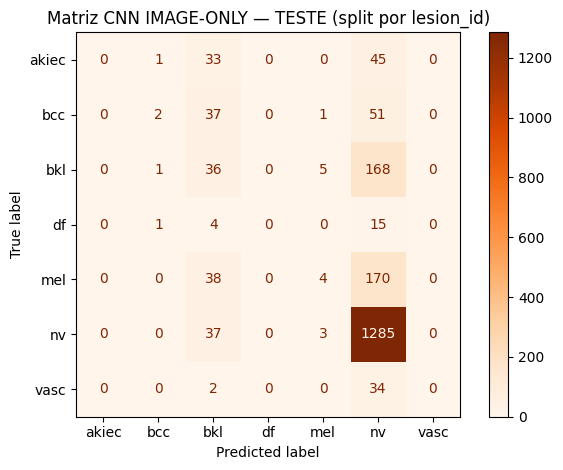

In [12]:
try:    model.load_weights('img_fase2.keras')
except: model.load_weights('img_fase1.keras')

y_true, y_pred = [], []
for Xb, yb in test_ds:
    p = model.predict(Xb, verbose=0)
    y_true.extend(np.argmax(yb.numpy(), axis=1))
    y_pred.extend(np.argmax(p, axis=1))

print("Relatorio IMAGE-ONLY (TESTE held-out por lesao):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap=plt.cm.Oranges, values_format='d')
plt.title('Matriz CNN IMAGE-ONLY — TESTE (split por lesion_id)')
plt.tight_layout(); plt.savefig('matrix_imageonly.png', dpi=150); plt.show()

In [13]:
extr_imgf = tf.keras.Model(model.inputs, model.get_layer("img_fused_256").output)
extr_gap  = tf.keras.Model(model.inputs, model.get_layer("image_gap").output)

def extract(paths, labels_enc):
    ds = make_img_dataset(paths, labels_enc, shuffle=False, augment=False)
    return extr_imgf.predict(ds, verbose=1), extr_gap.predict(ds, verbose=1)

f_tr, g_tr = extract(Ximg_tr, y_tr)
f_va, g_va = extract(Ximg_va, y_va)
f_te, g_te = extract(Ximg_te, y_te)
print("imgfused:", f_tr.shape, f_te.shape, "| gap:", g_tr.shape, g_te.shape)

219/219 ━━━━━━━━━━━━━━━━━━━━ 79s 295ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 71s 264ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 468ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 454ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 336ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 348ms/step
imgfused: (7006, 256) (1973, 256) | gap: (7006, 1536) (1973, 1536)


In [14]:
from google.colab import drive
drive.mount('/content/drive')
OUT = Path('/content/drive/MyDrive/ICV_imageonly_grouped')
OUT.mkdir(parents=True, exist_ok=True)
model.save(OUT / 'modelo_imageonly_grouped.keras')

def save_split(tag, f, g, y, les):
    np.save(OUT / f'X_{tag}_imgfused.npy', f)
    np.save(OUT / f'X_{tag}_gap.npy',      g)
    np.save(OUT / f'y_{tag}.npy',          np.asarray(y))
    np.save(OUT / f'lesion_{tag}.npy',     np.asarray(les))
save_split('train', f_tr, g_tr, y_tr, les_tr)
save_split('val',   f_va, g_va, y_va, les_va)
save_split('test',  f_te, g_te, y_te, les_te)

manifest = {
    "modelo": "image-only (EfficientNetB3 sem ramo clinico)",
    "classes": CLASS_NAMES,
    "split": {"train": int(len(train_idx)), "val": int(len(val_idx)), "test": int(len(test_idx))},
    "leakage_check": {"train_test": len(s_tr & s_te), "train_val": len(s_tr & s_va), "val_test": len(s_va & s_te)},
    "dist_teste": meta.iloc[test_idx]['dx'].value_counts().to_dict(),
    "split_method": "GroupShuffleSplit por lesion_id (70/10/20), random_state=42 — IDENTICO ao multimodal",
}
(OUT / 'split_manifest_imageonly.json').write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print("Salvo em:", OUT)
print(json.dumps(manifest, indent=2, ensure_ascii=False))

Mounted at /content/drive
Salvo em: /content/drive/MyDrive/ICV_imageonly_grouped
{
  "modelo": "image-only (EfficientNetB3 sem ramo clinico)",
  "classes": [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
  ],
  "split": {
    "train": 7006,
    "val": 979,
    "test": 1973
  },
  "leakage_check": {
    "train_test": 0,
    "train_val": 0,
    "val_test": 0
  },
  "dist_teste": {
    "nv": 1325,
    "mel": 212,
    "bkl": 210,
    "bcc": 91,
    "akiec": 79,
    "vasc": 36,
    "df": 20
  },
  "split_method": "GroupShuffleSplit por lesion_id (70/10/20), random_state=42 — IDENTICO ao multimodal"
}


## Próximos passos

1. Baixe de `ICV_imageonly_grouped/` os `X_*_imgfused.npy`, `X_*_gap.npy`, `y_*.npy`,
   `lesion_*.npy` e o `split_manifest_imageonly.json`.
2. Junte aos arquivos do notebook multimodal e me avise. Eu rodo o XGBoost/SMOTE
   sobre os embeddings dos **dois** modelos e monto a tabela:
   *image-only → XGBoost* **vs** *multimodal (fundido) → XGBoost* — respondendo de
   forma definitiva se os metadados clínicos somam ou são ruído.
3. **Verifique** que `dist_teste` e o nº de imagens batem com o manifesto do notebook
   multimodal — confirma que o conjunto de teste é o mesmo (comparação justa).
